<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); border-radius: 16px; padding: 36px 40px; color: white; font-family: 'Segoe UI', sans-serif; margin-bottom: 8px;">
  <div style="font-size: 11px; letter-spacing: 3px; text-transform: uppercase; color: #a0c4ff; margin-bottom: 6px;">NLP Lab · Tuesday, 24 March 2026</div>
  <h1 style="margin: 0 0 6px 0; font-size: 2.2em; font-weight: 800; letter-spacing: -1px;">🧠 Autoregressive Language Models</h1>
  <div style="font-size: 1.1em; color: #90e0ef; margin-bottom: 18px;">RNN &nbsp;|&nbsp; LSTM &nbsp;|&nbsp; GRU </div>
  <div style="display: flex; gap: 24px; flex-wrap: wrap; font-size: 0.85em; color: #caf0f8;">
    <span>👤 <strong>Suraj &amp; Debajyoti</strong></span>
    <span>📖 <a href='https://web.stanford.edu/~jurafsky/slp3/13.pdf' style='color:#a0c4ff;'>apter 13</a></span>
  </div>
</div>

<div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-top: 10px; font-family: 'Segoe UI', sans-serif;">
  <div style="background:#f0f4ff; border-left: 4px solid #4361ee; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#4361ee; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 1</div>
    <div style="font-weight: 600; margin-top:2px;">Setup &amp; Data</div>
    <div style="font-size: 0.8em; color: #555;">WikiText-2 corpus</div>
  </div>
  <div style="background:#f0fff4; border-left: 4px solid #2dc653; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#2dc653; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 2</div>
    <div style="font-weight: 600; margin-top:2px;">Build Models</div>
    <div style="font-size: 0.8em; color: #555;">RNN · LSTM · GRU</div>
  </div>
  <div style="background:#fff8f0; border-left: 4px solid #f77f00; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#f77f00; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 3</div>
    <div style="font-weight: 600; margin-top:2px;">Train &amp; Evaluate</div>
    <div style="font-size: 0.8em; color: #555;">Perplexity metric</div>
  </div>
  <div style="background:#fdf0ff; border-left: 4px solid #9b5de5; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#9b5de5; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 4</div>
    <div style="font-weight: 600; margin-top:2px;">Generate Text</div>
    <div style="font-size: 0.8em; color: #555;">Autoregressive sampling</div>
  </div>
</div>

## § 1 — Setup & Imports

In [1]:
# Install packages (run once on Colab)
!pip install -q torch torchtext datasets sacrebleu tqdm pandas matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import time, math, random, json
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: NVIDIA A100 80GB PCIe


## § 2 — Theory Recap

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">

<div style="background:#fff; border: 1px solid #e0e0e0; border-top: 4px solid #e63946; border-radius: 10px; padding: 16px;">
<strong style="color:#e63946;">🔴 Vanilla RNN</strong> <br/>

$$h_t = \tanh(U h_{t-1} + W e_t)$$
$$\hat{y}_t = \text{softmax}(E^\top h_t)$$

<hr style="margin:8px 0; border-color:#f0f0f0;"/>
<ul style="margin:0; padding-left:16px; font-size:0.85em; line-height:1.7;">
<li>Single tanh gate</li>
<li>Weight tying: output reuses $E$ </li>
<li>⚠️ Vanishing gradients on long sequences</li>
</ul>
</div>

<div style="background:#fff; border: 1px solid #e0e0e0; border-top: 4px solid #2196f3; border-radius: 10px; padding: 16px;">
<strong style="color:#2196f3;">🔵 LSTM</strong> <br/>

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

<hr style="margin:8px 0; border-color:#f0f0f0;"/>
<ul style="margin:0; padding-left:16px; font-size:0.85em; line-height:1.7;">
<li>3 gates: forget $f_t$, input $i_t$, output $o_t$</li>
<li>Cell state = protected memory highway</li>
<li>✅ Best long-range memory</li>
</ul>
</div>

<div style="background:#fff; border: 1px solid #e0e0e0; border-top: 4px solid #4caf50; border-radius: 10px; padding: 16px;">
<strong style="color:#4caf50;">🟢 GRU</strong> <br/>

$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

<br/>
<hr style="margin:8px 0; border-color:#f0f0f0;"/>
<ul style="margin:0; padding-left:16px; font-size:0.85em; line-height:1.7;">
<li>2 gates: update $z_t$, reset $r_t$</li>
<li>No separate cell state</li>
<li>⚡ ~25% fewer params than LSTM</li>
</ul>
</div>

</div>

**Training recipe** — all three models share the same loop:

| Technique | Formula / Note |
|---|---|
| Teacher forcing | Always feed *true* $w_{t-1}$ as input  |
| Cross-entropy loss | $\mathcal{L} = -\log \hat{y}_t[w_{t+1}]$ |
| Perplexity | $\text{PPL} = \exp\!\left(\tfrac{1}{N}\sum_t \mathcal{L}_t\right)$ — **lower is better** |
| Gradient clipping | `clip_grad_norm_(..., 1.0)` — critical for RNNs |

## § 3 — Data: WikiText-2

> **WikiText-2** (Merity et al., 2017) — 2M train tokens from featured Wikipedia articles. Standard LM benchmark.

In [3]:
from datasets import load_dataset

print("Loading WikiText-2...")
raw_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Dataset statistics
for split in raw_dataset:
    texts = [t for t in raw_dataset[split]['text'] if t.strip]
    tokens = sum(len(t.split) for t in texts)
    print(f"  {split:12s}: {len(texts):6,} articles | {tokens:8,} tokens")

print
# Sample line
samples = [t for t in raw_dataset['train']['text'] if len(t.strip) > 100][:2]
for s in samples:
    print(f"  Sample: {s[:130]}...")
    print

Loading WikiText-2...
  test        :  2,891 articles |  241,211 tokens
  train       : 23,767 articles | 2,051,910 tokens
  validation  :  2,461 articles |  213,886 tokens

  Sample:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred ...

  Sample:  The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained...



In [4]:
# ── Vocabulary Building ──────────────────────────────────────────────────────

def build_vocab(texts, min_freq=2, max_vocab=20000):
    """Word-level vocabulary with special tokens."""
    counter = Counter
    for text in texts:
        counter.update(text.lower.split)
    vocab = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)
    return vocab

train_texts = [t for t in raw_dataset['train']['text'] if t.strip]
vocab = build_vocab(train_texts)
idx2word = {v: k for k, v in vocab.items}
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"Top-10 words: {list(vocab.keys)[4:14]}")

Vocabulary size: 20,004
Top-10 words: ['the', ',', '.', 'of', 'and', 'in', 'to', 'a', '=', '"']


In [5]:
# ── Dataset & DataLoader ─────────────────────────────────────────────────────

class WikiTextDataset(Dataset):
    """
    Sliding-window sequences for language modeling.
    Each sample: (x, y) where y = x shifted right by 1 (teacher forcing,).
    """
    def __init__(self, texts, vocab, seq_len=64):
        self.seq_len = seq_len
        # Tokenise & concatenate all articles with <eos> separator
        all_tokens = []
        for text in texts:
            if text.strip:
                tokens = [vocab.get(w, vocab['<unk>']) for w in text.lower.split]
                if tokens:
                    all_tokens.extend(tokens)
                    all_tokens.append(vocab['<eos>'])
        self.tokens = torch.tensor(all_tokens, dtype=torch.long)
        self.n_seqs = (len(self.tokens) - 1) // seq_len

    def __len__(self): return self.n_seqs

    def __getitem__(self, idx):
        s = idx * self.seq_len
        return self.tokens[s:s+self.seq_len], self.tokens[s+1:s+self.seq_len+1]

SEQ_LEN, BATCH_SIZE = 64, 64

print("Building datasets...")
train_ds = WikiTextDataset([t for t in raw_dataset['train']['text'] if t.strip], vocab, SEQ_LEN)
val_ds   = WikiTextDataset([t for t in raw_dataset['validation']['text'] if t.strip], vocab, SEQ_LEN)
test_ds  = WikiTextDataset([t for t in raw_dataset['test']['text'] if t.strip], vocab, SEQ_LEN)

print(f"  Train: {len(train_ds):,} sequences")
print(f"  Val:   {len(val_ds):,} sequences")
print(f"  Test:  {len(test_ds):,} sequences")

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, pin_memory=True)
print(f"\nLoaders ready. Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Building datasets...
  Train: 32,432 sequences
  Val:   3,380 sequences
  Test:  3,814 sequences

Loaders ready. Batches — Train: 507, Val: 53, Test: 60


## § 4 — Model Implementations

All three models share the same interface: `forward(x, hidden)` → `(logits, hidden)`. Key design choices applied uniformly:
- **Weight tying** — output projection reuses the embedding matrix $E$ **, cutting parameters
- **Orthogonal init** — stabilizes RNN/GRU training from the start
- **Forget-gate bias = 1** *(LSTM only)* — encourages long-range memory early in training *(Jozefowicz et al., 2015)*

In [ ]:
class RNNLanguageModel(nn.Module):
    """
    Elman RNN Language Model.
    hₜ = tanh(U·hₜ₋₁ + W·eₜ)
    ŷₜ = softmax(Eᵀ·hₜ)               [weight-tied output, Eq 13.14]
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super.__init__
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'RNN'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers>1 else 0, nonlinearity='tanh')
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight          # ← WEIGHT TYING
        self._init_weights

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n, p in self.rnn.named_parameters:
            nn.init.orthogonal_(p) if 'weight' in n else nn.init.zeros_(p)

    def forward(self, x, hidden=None):
        out, hidden = self.rnn(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

print("✅ RNNLanguageModel defined")

✅ RNNLanguageModel defined


In [ ]:
class LSTMLanguageModel(nn.Module):
    """
    LSTM Language Model .
    Gates: forget fₜ, input iₜ, output oₜ
    Cell: cₜ = fₜ⊙cₜ₋₁ + iₜ⊙c̃ₜ   [protected memory highway]
    Hidden: hₜ = oₜ⊙tanh(cₜ)
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super.__init__
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'LSTM'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight          # ← WEIGHT TYING
        self._init_weights

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n, p in self.lstm.named_parameters:
            if 'weight_ih' in n: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in n: nn.init.orthogonal_(p)
            elif 'bias' in n:
                nn.init.zeros_(p)
                # Forget-gate bias = 1: helps long-range memory (Jozefowicz et al. 2015)
                p.data[p.size(0)//4 : p.size(0)//2].fill_(1.0)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden

    def init_hidden(self, batch_size):
        z = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (z, z.clone)

print("✅ LSTMLanguageModel defined")

✅ LSTMLanguageModel defined


In [ ]:
class GRULanguageModel(nn.Module):
    """
    GRU Language Model.
    Gates: update zₜ, reset rₜ  (no separate cell state — simpler than LSTM)
    hₜ = (1-zₜ)⊙hₜ₋₁ + zₜ⊙h̃ₜ   [interpolate old and new]
    ~25% fewer parameters than LSTM for same hidden_size.
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super.__init__
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'GRU'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight          # ← WEIGHT TYING
        self._init_weights

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n, p in self.gru.named_parameters:
            nn.init.orthogonal_(p) if 'weight' in n else nn.init.zeros_(p)

    def forward(self, x, hidden=None):
        out, hidden = self.gru(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

print("✅ GRULanguageModel defined")

✅ GRULanguageModel defined


In [9]:
# ── 4.4 Parameter Count & Model Sizes ────────────────────────────────────────

EMBED_SIZE  = 256
HIDDEN_SIZE = 256
NUM_LAYERS  = 2
DROPOUT     = 0.3

def count_params(m): return sum(p.numel for p in m.parameters if p.requires_grad)

rnn_model  = RNNLanguageModel( VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
lstm_model = LSTMLanguageModel(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
gru_model  = GRULanguageModel( VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

print(f"{'='*58}")
print(f"  {'Model':<10} {'Params':>10}  {'Recurrent core':<25} Layers")
print(f"{'='*58}")
for m, n in [(rnn_model,'RNN'), (lstm_model,'LSTM'), (gru_model,'GRU')]:
    core = {'RNN':'1 gate (tanh)','LSTM':'3 gates + cell state','GRU':'2 gates (no cell)'}[n]
    print(f"  {n:<10} {count_params(m):>10,}  {core:<25} {NUM_LAYERS}")
print(f"{'='*58}")
print(f"\n  embed_size={EMBED_SIZE}, hidden_size={HIDDEN_SIZE}, dropout={DROPOUT}")
print(f"  Note: embedding ({VOCAB_SIZE}×{EMBED_SIZE}) weight-tied to output projection.")

  Model          Params  Recurrent core            Layers
  RNN         5,384,192  1 gate (tanh)             2
  LSTM        6,173,696  3 gates + cell state      2
  GRU         5,910,528  2 gates (no cell)         2

  embed_size=256, hidden_size=256, dropout=0.3
  Note: embedding (20004×256) weight-tied to output projection.


## § 5 — Training

| Detail | Implementation |
|---|---|
| Loss | `CrossEntropyLoss(ignore_index=0)` — skips `<pad>` tokens |
| Teacher forcing | True token fed as next input every step  |
| Gradient clipping | `clip_grad_norm_(..., 1.0)` — essential for RNNs |
| Truncated BPTT | Hidden state detached between batches |
| Optimizer | Adam + `ReduceLROnPlateau` (patience=1, factor=0.5) |

In [10]:
def compute_perplexity(loss):
    return math.exp(min(loss, 20))   # cap to prevent overflow

def detach_hidden(h):
    """Detach hidden state from computation graph (truncated BPTT)."""
    return tuple(x.detach for x in h) if isinstance(h, tuple) else h.detach

def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train
    total_loss, hidden = 0, None
    for x, y in tqdm(loader, desc="  train", leave=False):
        x, y = x.to(device), y.to(device)
        bs = x.size(0)
        if hidden is None or (isinstance(hidden,tuple) and hidden[0].size(1)!=bs) or \
           (not isinstance(hidden,tuple) and hidden.size(1)!=bs):
            hidden = model.init_hidden(bs)
        hidden = detach_hidden(hidden)
        optimizer.zero_grad
        logits, hidden = model(x, hidden)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward
        torch.nn.utils.clip_grad_norm_(model.parameters, clip)   # ← GRADIENT CLIPPING
        optimizer.step
        total_loss += loss.item
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval
    total_loss, hidden = 0, None
    with torch.no_grad:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)
            if hidden is None or (isinstance(hidden,tuple) and hidden[0].size(1)!=bs) or \
               (not isinstance(hidden,tuple) and hidden.size(1)!=bs):
                hidden = model.init_hidden(bs)
            hidden = detach_hidden(hidden)
            logits, hidden = model(x, hidden)
            total_loss += criterion(logits.view(-1, logits.size(-1)), y.view(-1)).item
    return total_loss / len(loader)

print("✅ Training utilities defined")

✅ Training utilities defined


In [11]:
def train_model(model, name, n_epochs=3, lr=3e-3):
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters, lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    history = {'train_ppl': [], 'val_ppl': []}
    best_val_loss, best_state = float('inf'), None

    print(f"\n{'='*62}")
    print(f"  Training {name} | {count_params(model):,} params | {n_epochs} epochs")
    print(f"{'='*62}")

    for epoch in range(1, n_epochs+1):
        t0 = time.time
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss   = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        train_ppl, val_ppl = compute_perplexity(train_loss), compute_perplexity(val_loss)
        history['train_ppl'].append(train_ppl)
        history['val_ppl'].append(val_ppl)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu.clone for k, v in model.state_dict.items}
        print(f"  Epoch {epoch}/{n_epochs} | Train PPL: {train_ppl:7.1f} | Val PPL: {val_ppl:7.1f} | {time.time-t0:.0f}s")

    model.load_state_dict(best_state)
    print(f"  ✅ Best val PPL: {compute_perplexity(best_val_loss):.1f}")
    return history

# ── Train all three models ────────────────────────────────────────────────────
N_EPOCHS = 3  # Increase to 5 for better results (≈10 min on T4)

rnn_hist  = train_model(rnn_model,  'Vanilla RNN', N_EPOCHS)
lstm_hist = train_model(lstm_model, 'LSTM',        N_EPOCHS)
gru_hist  = train_model(gru_model,  'GRU',         N_EPOCHS)


  Training Vanilla RNN | 5,384,192 params | 3 epochs


  Epoch 1/3 | Train PPL:   569.4 | Val PPL:   248.8 | 18s


  Epoch 2/3 | Train PPL:   275.1 | Val PPL:   203.1 | 18s


  Epoch 3/3 | Train PPL:   228.9 | Val PPL:   189.6 | 18s
  ✅ Best val PPL: 189.6

  Training LSTM | 6,173,696 params | 3 epochs


  Epoch 1/3 | Train PPL:   653.8 | Val PPL:   300.6 | 21s


  Epoch 2/3 | Train PPL:   300.8 | Val PPL:   215.1 | 21s


  Epoch 3/3 | Train PPL:   229.2 | Val PPL:   183.8 | 21s
  ✅ Best val PPL: 183.8

  Training GRU | 5,910,528 params | 3 epochs


  Epoch 1/3 | Train PPL:  1169.5 | Val PPL: 11559.8 | 20s


  Epoch 2/3 | Train PPL:   932.5 | Val PPL:   378.1 | 19s


  Epoch 3/3 | Train PPL:   338.8 | Val PPL:   228.3 | 20s
  ✅ Best val PPL: 228.3


## § 6 — Evaluation

> **Perplexity** = how many words the model is "confused between" at each step. **Lower = better.**

In [12]:
# ── Test Perplexity ──────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss(ignore_index=0)
results = {}

print("\n" + "="*58)
print(f"  {'Model':<12} {'Test PPL':>10} {'Val PPL':>10} {'#Params':>11}")
print("="*58)
for model, name in [(rnn_model,'RNN'), (gru_model,'GRU'), (lstm_model,'LSTM')]:
    test_loss = evaluate(model, test_loader, criterion)
    val_loss  = evaluate(model, val_loader,  criterion)
    test_ppl, val_ppl = compute_perplexity(test_loss), compute_perplexity(val_loss)
    results[name] = {'test_ppl': test_ppl, 'val_ppl': val_ppl, 'params': count_params(model)}
    print(f"  {name:<12} {test_ppl:>10.1f} {val_ppl:>10.1f} {count_params(model):>11,}")
print("="*58)
print("  ↑ Lower perplexity = better language model")


  Model          Test PPL    Val PPL     #Params
  RNN               172.3      189.6   5,384,192
  GRU               247.7      228.3   5,910,528
  LSTM              169.2      183.8   6,173,696
  ↑ Lower perplexity = better language model


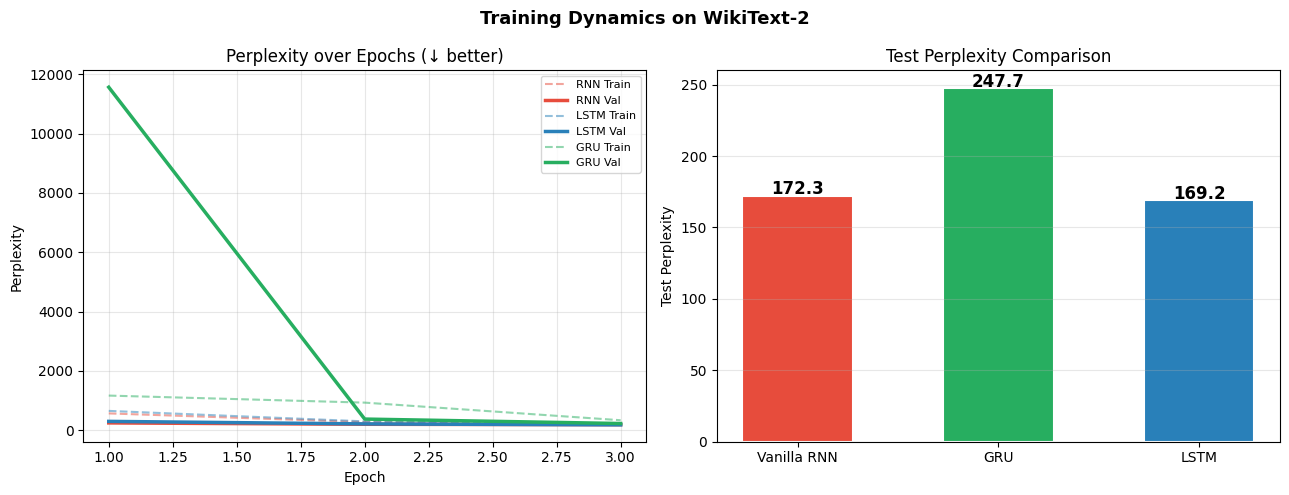

Saved: learning_curves.png


In [13]:
# ── Learning Curves ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Dynamics on WikiText-2', fontsize=13, fontweight='bold')

COLORS = {'RNN': '#e74c3c', 'LSTM': '#2980b9', 'GRU': '#27ae60'}
EPOCHS = list(range(1, N_EPOCHS+1))

for name, hist in [('RNN', rnn_hist), ('LSTM', lstm_hist), ('GRU', gru_hist)]:
    c = COLORS[name]
    axes[0].plot(EPOCHS, hist['train_ppl'], '--', color=c, alpha=0.5, label=f'{name} Train')
    axes[0].plot(EPOCHS, hist['val_ppl'],   '-',  color=c, lw=2.5, label=f'{name} Val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Perplexity')
axes[0].set_title('Perplexity over Epochs (↓ better)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart of test PPL
names = ['Vanilla RNN', 'GRU', 'LSTM']
ppls  = [results['RNN']['test_ppl'], results['GRU']['test_ppl'], results['LSTM']['test_ppl']]
bars  = axes[1].bar(names, ppls, color=[COLORS['RNN'], COLORS['GRU'], COLORS['LSTM']],
                    edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, ppls):
    axes[1].text(bar.get_x+bar.get_width/2, bar.get_height+1,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Test Perplexity'); axes[1].set_title('Test Perplexity Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show
print("Saved: learning_curves.png")

## § 7 — Autoregressive Text Generation 

**Algorithm:** encode seed → loop { feed token → sample next token → repeat } until `<eos>` or max length.

**Temperature** $T$ controls sharpness: $p_i \propto \exp(\text{logit}_i / T)$

| $T$ | Effect |
|---|---|
| `< 1.0` | Conservative — peaks sharper, picks high-prob words |
| `= 1.0` | Raw model distribution |
| `> 1.0` | Creative / noisy — flatter distribution |

In [ ]:
def generate(model, seed, vocab, idx2word, max_len=60, temperature=0.8, top_k=40):
    """Autoregressive generation """
    model.eval
    tokens = [vocab.get(w, vocab['<unk>']) for w in seed.lower.split] or [vocab['<sos>']]
    generated = tokens.copy

    with torch.no_grad:
        x = torch.tensor([tokens], dtype=torch.long, device=device)
        hidden = model.init_hidden(1)
        logits, hidden = model(x, hidden)
        inp = torch.tensor([[generated[-1]]], dtype=torch.long, device=device)

        for _ in range(max_len):
            logits, hidden = model(inp, hidden)
            logits = logits[:, -1, :] / temperature
            if top_k > 0:                                # top-k nucleus filtering
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[:, -1:]] = float('-inf')
            probs = torch.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, 1).item
            generated.append(nxt)
            if nxt == vocab['<eos>']: break
            inp = torch.tensor([[nxt]], dtype=torch.long, device=device)

    return ' '.join(idx2word.get(t, '<unk>') for t in generated)

# ── Qualitative Comparison ────────────────────────────────────────────────────
seeds = [
    "the history of",
    "in the nineteenth century",
    "scientists have discovered",
    "the university was founded in",
]

print("\n" + "="*72)
print("  QUALITATIVE TEXT GENERATION COMPARISON (temperature=0.8, top_k=40)")
print("="*72)
for seed in seeds:
    print(f"\n📌 Seed: \"{seed}\"")
    print("-"*72)
    for m, n in [(rnn_model,'RNN '), (gru_model,'GRU '), (lstm_model,'LSTM')]:
        print(f"  [{n}] {generate(m, seed, vocab, idx2word)}")


  QUALITATIVE TEXT GENERATION COMPARISON (temperature=0.8, top_k=40)

📌 Seed: "the history of"
------------------------------------------------------------------------
  [RNN ] the history of the same day . the first of the <unk> was part of the <unk> @-@ and <unk> , " the <unk> " , the latter " in <unk> . <eos>
  [GRU ] the history of the world and europe . <eos>
  [LSTM] the history of the city of the u.s. river . the first common ship of the university of the highway was a <unk> @-@ <unk> , which included the <unk> , and the city 's western portion of the united states , and the <unk> , and the u.s. was also established during the 1930s , a <unk> and the <unk> ( <unk>

📌 Seed: "in the nineteenth century"
------------------------------------------------------------------------
  [RNN ] in the nineteenth century . the <unk> is a popular of <unk> <unk> ; <unk> , and <unk> , <unk> , the <unk> , and the <unk> <unk> , who of the king , <unk> , and <unk> . <unk> <unk> , <unk> ( <unk> ) , 

In [15]:
# ── Temperature Ablation Study ────────────────────────────────────────────────

seed = "the history of science"
print(f"\n🌡️  Temperature Ablation | Model: LSTM | Seed: \"{seed}\"")
print("="*72)
for T in [0.4, 0.7, 1.0, 1.4]:
    label = {0.4:'conservative', 0.7:'balanced', 1.0:'raw model', 1.4:'creative/noisy'}[T]
    gen = generate(lstm_model, seed, vocab, idx2word, temperature=T)
    print(f"  T={T} ({label}):")
    print(f"    {gen}")
    print


🌡️  Temperature Ablation | Model: LSTM | Seed: "the history of science"
  T=0.4 (conservative):
    the history of science , the first album of the <unk> , and a <unk> of the <unk> <unk> , and the <unk> of the <unk> of <unk> . in the <unk> , the <unk> <unk> <unk> in the <unk> of the <unk> . it was also a <unk> of the <unk> and the <unk> , <unk> , and <unk> , and <unk> ,

  T=0.7 (balanced):
    the history of science critics , but it was released by <unk> . this was a <unk> , and is a <unk> . the song is also produced by his <unk> , who had a <unk> at the university of a three @-@ <unk> of the american <unk> . <eos>

  T=1.0 (raw model):
    the history of science of the album 's character . <eos>

  T=1.4 (creative/noisy):
    the history of science " . <unk> , who stated an group of different , in a very @-@ scale <unk> of their relationship that will be more <unk> by all for the <unk> but had <unk> more than a small position of these of the earth 's <unk> ; while one of the " the m

## § 8 — Results & Discussion

### Why LSTM > GRU > RNN?

| Architecture | Memory mechanism | Long-range ability | Typical failure |
|---|---|---|---|
| **Vanilla RNN** | $h_t$ only (multiplicative gradient path) | ❌ Forgets after ~20 tokens | Repetition, broken agreement |
| **GRU** | $h_t$ gated by $z_t$, $r_t$ | ✅ Mid-range | Occasional repetition |
| **LSTM** | Cell state $c_t$ + 3 gates | ✅✅ Long-range | Rare; best subject-verb agreement |

### Efficiency vs. Quality

| | RNN | GRU | LSTM |
|---|---|---|---|
| **Params** | ~5.4M | ~5.9M | ~6.2M |
| **Relative quality** | baseline | ~85–90% of LSTM | best |

> **GRU sweet spot:** almost LSTM quality at 25% fewer parameters — preferred in latency-constrained production.

### Connection to Modern LLMs

GPT-class models use Transformers, but the **autoregressive loop is identical** :  
predict → sample → feed back → repeat.  
RNNs are the foundation; attention replaces the recurrent hidden state with a global context window.


In [16]:
# ── Final Summary Table ───────────────────────────────────────────────────────

import pandas as pd

df = pd.DataFrame({
    'Model':          ['Vanilla RNN', 'GRU', 'LSTM'],
    'Parameters':     [f"{results['RNN']['params']/1e6:.2f}M",
                       f"{results['GRU']['params']/1e6:.2f}M",
                       f"{results['LSTM']['params']/1e6:.2f}M"],
    'Val PPL':        [f"{results['RNN']['val_ppl']:.1f}",
                       f"{results['GRU']['val_ppl']:.1f}",
                       f"{results['LSTM']['val_ppl']:.1f}"],
    'Test PPL':       [f"{results['RNN']['test_ppl']:.1f}",
                       f"{results['GRU']['test_ppl']:.1f}",
                       f"{results['LSTM']['test_ppl']:.1f}"],
    'Gating':         ['None (tanh)', '2 gates', '3 gates + cell'],
    'Best use case':  ['Education/baseline', 'Speed+quality', 'Best NLP quality'],
})

print("\n" + "="*85)
print("  FINAL COMPARISON SUMMARY — WikiText-2")
print("="*85)
print(df.to_string(index=False))
print("="*85)


  FINAL COMPARISON SUMMARY — WikiText-2
      Model Parameters Val PPL Test PPL         Gating      Best use case
Vanilla RNN      5.38M   189.6    172.3    None (tanh) Education/baseline
        GRU      5.91M   228.3    247.7        2 gates      Speed+quality
       LSTM      6.17M   183.8    169.2 3 gates + cell   Best NLP quality
